# Visium HD mouse brain (Fig. S9)

CellSweep on a standard (non-xenograft) Visium HD tissue: the 10x Genomics fresh-frozen Visium HD 3' mouse brain
section (Space Ranger 4.0.1, 8 µm bins; https://www.10xgenomics.com/datasets/visium-hd-three-prime-mouse-brain-fresh-frozen).
The workflow mirrors `spatial.ipynb`: bins below the knee-plot UMI cutoff or outside the tissue are empty, Leiden
(resolution 1.0) on the non-empty bins gives the cell-type labels, and CellSweep runs with default settings.

Leiden labels depend on the scanpy/umap/numba versions, so the paper's run uses the saved labels of the original
run (`celltype_leiden_original.csv`, 30 clusters) when that file is present; delete it or set `labels_csv = None`
to recluster.

In [1]:
import os
import json
import subprocess
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.colors import ListedColormap, to_rgba
from matplotlib.font_manager import FontProperties, findfont
from matplotlib.lines import Line2D
from matplotlib.transforms import Affine2D
from PIL import Image, ImageDraw, ImageFont
from scipy import ndimage as ndi
from IPython.display import Image as show_image, display

from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", "visium_mouse_brain")
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "visium_mouse_brain")
markers_out_dir = os.path.join(out_dir, "reviewer7")
panel_dir = os.path.join(out_dir, "panels")
for d in [data_dir, out_dir, markers_out_dir, panel_dir]:
    os.makedirs(d, exist_ok=True)
adata_path_cellsweep = os.path.join(data_dir, "adata_cellsweep.h5ad")

base_url = "https://cf.10xgenomics.com/samples/spatial-exp/4.0.1/Visium_HD_3prime_Mouse_Brain/Visium_HD_3prime_Mouse_Brain"
resolution = "008um"
expected_cells = 350_000  # ~93% of the 376,419 in-tissue bins; the brain section is contiguous tissue
leiden_resolution = 1.0
labels_csv = os.path.join(data_dir, "celltype_leiden_original.csv")
if not os.path.exists(labels_csv):
    labels_csv = None
threads = 32
verbose = 1
overwrite = False   # rerun CellSweep even if its output exists

## 1. CellSweep

In [2]:

for name in ["binned_outputs", "segmented_outputs"]:
    if not os.path.exists(os.path.join(data_dir, name)):
        subprocess.run(["wget", "-O", f"{data_dir}/{name}.tar.gz", f"{base_url}_{name}.tar.gz"], check=True)
        subprocess.run(["tar", "-xzf", f"{data_dir}/{name}.tar.gz", "-C", data_dir], check=True)

if os.path.exists(adata_path_cellsweep) and not overwrite:
    print(f"{adata_path_cellsweep} exists, skipping")
else:
    matrix_dir_raw = os.path.join(data_dir, "binned_outputs", f"square_{resolution}")
    adata_raw = cs_utils.load_adata(os.path.join(matrix_dir_raw, "raw_feature_bc_matrix.h5"))
    adata_raw.var_names_make_unique()
    spatial_df = pd.read_parquet(os.path.join(matrix_dir_raw, "spatial", "tissue_positions.parquet"))
    adata_raw.obs = adata_raw.obs.merge(spatial_df.set_index("barcode"), left_index=True, right_index=True, how="left")
    adata_raw.obsm["spatial"] = adata_raw.obs[["pxl_col_in_fullres", "pxl_row_in_fullres"]].to_numpy()

    umi_cutoff = cs_utils.knee_plot(adata_raw, transpose=True, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"), show=False)
    adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)
    adata_raw.obs["is_empty"] = adata_raw.obs["is_empty"] | (~adata_raw.obs["in_tissue"].fillna(False).astype(bool))
    print(f"non-empty bins: {(~adata_raw.obs['is_empty']).sum()}")

    if labels_csv is not None:
        labels = pd.read_csv(labels_csv, index_col=0)["celltype"].astype(str).reindex(adata_raw.obs.index)
        assert labels.notna().all() and ((labels == "empty") == adata_raw.obs["is_empty"]).all(), "labels do not match the empty-bin calls"
        adata_raw.obs["celltype"] = labels.astype("category")
    else:
        adata_processed_tmp = adata_raw[~adata_raw.obs["is_empty"]].copy()
        adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=None, min_cells=None, max_mt_percentage=None, n_top_genes=2000, n_pcs=50, n_neighbors=15, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
        adata_raw.obs["celltype"] = adata_processed_tmp.obs["leiden"].reindex(adata_raw.obs.index).astype(str).replace("nan", "empty").astype("category")

    denoise_count_matrix(adata_raw, adata_out=adata_path_cellsweep, freeze_ambient_profile=True, empty_droplet_method="threshold", threads=threads, verbose=verbose, log_file=os.path.join(data_dir, "cellsweep.log"))

/home/mcaskey/cellsweep/notebooks/data/visium_mouse_brain/adata_cellsweep.h5ad exists, skipping


## 2. Marker specificity without ground truth

A. Spatially restricted genes (genome-wide). For every gene with ≥ 2,000 raw counts, the raw counts are smoothed
(Gaussian, 3 bins) and the gene's source is the set of bins holding the top 50% of the smoothed mass, dilated by
40 µm. Genes whose source covers ≤ 5% of the tissue are spatially restricted (e.g. Ttr: choroid plexus; Pmch: lateral
hypothalamus); broadly expressed genes (≥ 25%) are the control. Counts of a restricted gene far from its source cannot
come from the source cells.

B. Cluster markers with labels independent of CellSweep: Space Ranger graph-based clusters and differential
expression. For the top 10 markers of each cluster, the fraction of the marker's counts in its own cluster before and
after correction, and the fraction of in-cluster counts retained; controls are ubiquitous genes (lowest across-cluster
variation).

Every retention is also compared with the retention expected if the gene's counts were removed at the same rate as all
counts in the same bins (expected = Σ_bins raw_g · r_bin / Σ_bins raw_g, with r_bin the bin's CellSweep/raw total).

In [ ]:
BIN_UM = 8
SIGMA_BINS = 3
SOURCE_DILATE_UM = 40
MAX_SOURCE_AREA = 0.05
BROAD_MIN_AREA = 0.25
MIN_GENE_COUNTS = 2000
FAR_UM = 400
N_MARKERS = 10
EXAMPLE_GENES = ["Ttr", "Pmch"]
DIST_EDGES = [0, 40, 100, 200, 400, 800, 1600, np.inf]
_G = {}  # per-process globals for the gene loop


def _init(rows, cols, shape, tissue, raw_cols, cs_cols, bin_retention):
    _G.update(rows=rows, cols=cols, shape=shape, tissue=tissue, raw=raw_cols, cs=cs_cols, r=bin_retention)


def gene_source_stats(j):
    rows, cols, shape, tissue = _G["rows"], _G["cols"], _G["shape"], _G["tissue"]
    raw = np.asarray(_G["raw"][:, j].todense()).ravel()
    cs = np.asarray(_G["cs"][:, j].todense()).ravel()
    grid = np.zeros(shape)
    np.add.at(grid, (rows, cols), raw)
    smooth = ndi.gaussian_filter(grid, SIGMA_BINS)
    vals = smooth[rows, cols]
    order = np.argsort(vals)[::-1]
    n_top = np.searchsorted(np.cumsum(vals[order]), 0.5 * vals.sum()) + 1
    core = np.zeros(shape, dtype=bool)
    core[rows[order[:n_top]], cols[order[:n_top]]] = True
    dist = ndi.distance_transform_edt(~core) * BIN_UM
    d = dist[rows, cols]
    on = d <= SOURCE_DILATE_UM
    far = d > FAR_UM
    return {
        "j": j,
        "source_area_frac": on.sum() / tissue,
        "raw_total": raw.sum(), "cs_total": cs.sum(),
        "raw_on": raw[on].sum(), "cs_on": cs[on].sum(),
        "raw_far": raw[far].sum(), "cs_far": cs[far].sum(),
        "expected_on": (raw[on] * _G["r"][on]).sum(), "expected_far": (raw[far] * _G["r"][far]).sum(),
        "raw_decay": np.array([raw[(d > lo) & (d <= hi)].mean() if ((d > lo) & (d <= hi)).any() else np.nan for lo, hi in zip(DIST_EDGES[:-1], DIST_EDGES[1:])]),
        "cs_decay": np.array([cs[(d > lo) & (d <= hi)].mean() if ((d > lo) & (d <= hi)).any() else np.nan for lo, hi in zip(DIST_EDGES[:-1], DIST_EDGES[1:])]),
    }


def load():
    adata = ad.read_h5ad(adata_path_cellsweep)
    adata = adata[~adata.obs["is_empty"].astype(bool)].copy()
    raw = adata.layers["raw"].tocsc()
    cs = adata.X.tocsc()
    return adata, raw, cs


def analysis_restricted_genes(adata, raw, cs):
    rows, cols = adata.obs["array_row"].values, adata.obs["array_col"].values
    shape = (rows.max() + 1, cols.max() + 1)
    totals = np.asarray(raw.sum(axis=0)).ravel()
    genes = np.where(totals >= MIN_GENE_COUNTS)[0]
    print(f"genes with >= {MIN_GENE_COUNTS} counts: {len(genes)}")
    bin_retention = np.asarray(cs.sum(axis=1)).ravel() / np.maximum(np.asarray(raw.sum(axis=1)).ravel(), 1e-12)
    with ProcessPoolExecutor(max_workers=threads, initializer=_init, initargs=(rows, cols, shape, len(rows), raw, cs, bin_retention)) as ex:
        results = list(ex.map(gene_source_stats, genes, chunksize=8))
    decay = {adata.var_names[r["j"]]: (r.pop("raw_decay"), r.pop("cs_decay")) for r in results}
    df = pd.DataFrame(results)
    df.index = adata.var_names[df.pop("j")]
    df["on_source_frac_raw"] = df["raw_on"] / df["raw_total"]
    df["on_source_frac_cs"] = df["cs_on"] / df["cs_total"]
    df["pct_on_source_removed"] = 100 * (1 - df["cs_on"] / df["raw_on"])
    df["pct_far_removed"] = 100 * (1 - df["cs_far"] / df["raw_far"].replace(0, np.nan))
    df["pct_total_removed"] = 100 * (1 - df["cs_total"] / df["raw_total"])
    df["on_source_obs_over_expected"] = df["cs_on"] / df["expected_on"]
    df["far_obs_over_expected"] = df["cs_far"] / df["expected_far"].replace(0, np.nan)
    df["class"] = np.where(df["source_area_frac"] <= MAX_SOURCE_AREA, "restricted", np.where(df["source_area_frac"] >= BROAD_MIN_AREA, "broad", "intermediate"))
    df.to_csv(os.path.join(markers_out_dir, "restricted_genes_source_stats.csv"))

    summary = df.groupby("class").agg(n_genes=("raw_total", "size"), median_on_source_frac_raw=("on_source_frac_raw", "median"), median_on_source_frac_cs=("on_source_frac_cs", "median"), median_pct_on_source_removed=("pct_on_source_removed", "median"), median_pct_far_removed=("pct_far_removed", "median"), median_pct_total_removed=("pct_total_removed", "median"), median_on_source_obs_over_expected=("on_source_obs_over_expected", "median"), median_far_obs_over_expected=("far_obs_over_expected", "median"))
    summary.to_csv(os.path.join(markers_out_dir, "restricted_genes_summary.csv"))
    print(summary.round(3).to_string())
    restricted = df[df["class"] == "restricted"]
    print(f"restricted genes with increased on-source fraction: {(restricted['on_source_frac_cs'] > restricted['on_source_frac_raw']).mean() * 100:.1f}%")
    print(restricted.sort_values("raw_total", ascending=False).head(25)[["raw_total", "source_area_frac", "on_source_frac_raw", "on_source_frac_cs", "pct_on_source_removed", "pct_far_removed", "on_source_obs_over_expected", "far_obs_over_expected"]].round(3).to_string())

    # figures: example decay curves + genome-wide scatter
    fig, axes = plt.subplots(1, len(EXAMPLE_GENES) + 1, figsize=(5 * (len(EXAMPLE_GENES) + 1), 4.2))
    labels = [f"{int(lo)}-{int(hi)}" if np.isfinite(hi) else f">{int(lo)}" for lo, hi in zip(DIST_EDGES[:-1], DIST_EDGES[1:])]
    for ax, g in zip(axes, EXAMPLE_GENES):
        if g not in decay:
            continue
        r, c = decay[g]
        ax.plot(labels, r, "-o", color="#a6c8ff", label="raw")
        ax.plot(labels, c, "-o", color="#0047b3", label="cellsweep")
        ax.set_yscale("log")
        ax.set_title(f"{g}: {df.loc[g, 'pct_on_source_removed']:.0f}% removed at source, {df.loc[g, 'pct_far_removed']:.0f}% >{FAR_UM} um away")
        ax.set_xlabel("Distance from source region (um)")
        ax.set_ylabel("Mean counts per bin")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(frameon=False)
    ax = axes[-1]
    for cls, color in [("broad", "#bbbbbb"), ("intermediate", "#8da0cb"), ("restricted", "#d62728")]:
        d = df[df["class"] == cls]
        ax.scatter(d["on_source_frac_raw"], d["on_source_frac_cs"], s=6, color=color, alpha=0.6, label=f"{cls} (n={len(d)})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlabel("Fraction of gene counts in source region (raw)")
    ax.set_ylabel("... (cellsweep)")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    fig.savefig(os.path.join(markers_out_dir, "restricted_genes.png"), dpi=200, bbox_inches="tight")
    plt.close(fig)

    # spatial maps of the example genes
    fig, axes = plt.subplots(2, len(EXAMPLE_GENES), figsize=(6 * len(EXAMPLE_GENES), 11), squeeze=False)
    for j, g in enumerate(EXAMPLE_GENES):
        gi = adata.var_names.get_loc(g)
        for i, (mat, name) in enumerate([(raw, "raw"), (cs, "cellsweep")]):
            v = np.asarray(mat[:, gi].todense()).ravel()
            ax = axes[i, j]
            order = np.argsort(v)
            ax.scatter(cols[order], -rows[order], c=np.log1p(v[order]), s=0.05, cmap="magma", vmin=0, vmax=np.log1p(np.asarray(raw[:, gi].todense()).max()))
            ax.set_title(f"{g} ({name}), log1p counts")
            ax.set_aspect("equal")
            ax.axis("off")
    fig.tight_layout()
    fig.savefig(os.path.join(markers_out_dir, "restricted_gene_maps.png"), dpi=200, bbox_inches="tight")
    plt.close(fig)
    return df


def analysis_cluster_markers(adata, raw, cs):
    ana = os.path.join(data_dir, "binned_outputs", "square_008um", "analysis")
    clusters = pd.read_csv(os.path.join(ana, "clustering", "gene_expression_graphclust", "clusters.csv"), index_col=0)["Cluster"]
    de = pd.read_csv(os.path.join(ana, "diffexp", "gene_expression_graphclust", "differential_expression.csv"))
    labels = clusters.reindex(adata.obs_names)
    keep = labels.notna().values
    labels = labels[keep].astype(int).values
    raw, cs = raw.tocsr()[keep], cs.tocsr()[keep]
    print(f"bins with Space Ranger graphclust label: {keep.sum()} / {len(keep)}; clusters: {len(np.unique(labels))}")
    gene_index = pd.Index(adata.var_names)

    K = np.unique(labels)
    onehot = np.zeros((len(labels), len(K)))
    onehot[np.arange(len(labels)), np.searchsorted(K, labels)] = 1
    import scipy.sparse as sp
    L = sp.csr_matrix(onehot)
    raw_by_cluster = np.asarray((L.T @ raw).todense())   # K x G sums
    cs_by_cluster = np.asarray((L.T @ cs).todense())
    bin_retention = np.asarray(cs.sum(axis=1)).ravel() / np.maximum(np.asarray(raw.sum(axis=1)).ravel(), 1e-12)
    expected_by_cluster = np.asarray((L.T @ sp.diags(bin_retention) @ raw).todense())  # K x G, raw counts weighted by bin retention
    sizes = onehot.sum(axis=0)

    rows = []
    for k in K:
        col_fc, col_p, col_mean = f"Cluster {k} Log2 fold change", f"Cluster {k} Adjusted p value", f"Cluster {k} Mean Counts"
        cand = de[(de[col_p] < 0.05) & (de[col_mean] >= 0.1) & de["Feature Name"].isin(gene_index)].sort_values(col_fc, ascending=False).head(N_MARKERS)
        for g in cand["Feature Name"]:
            rows.append((k, g, "marker"))
    # controls: highly expressed genes with the lowest across-cluster CV of mean expression
    means = raw_by_cluster / sizes[:, None]
    expr = np.asarray(raw.sum(axis=0)).ravel()
    top = np.argsort(expr)[::-1][:500]
    cv = means[:, top].std(axis=0) / means[:, top].mean(axis=0)
    for gi in top[np.argsort(cv)[:30]]:
        rows.append((K[np.argmax(means[:, gi])], adata.var_names[gi], "ubiquitous control"))

    out = []
    for k, g, kind in rows:
        gi = gene_index.get_loc(g)
        ki = np.searchsorted(K, k)
        r_tot, c_tot = raw_by_cluster[:, gi].sum(), cs_by_cluster[:, gi].sum()
        r_in, c_in = raw_by_cluster[ki, gi], cs_by_cluster[ki, gi]
        r_other_mean = (r_tot - r_in) / (sizes.sum() - sizes[ki])
        c_other_mean = (c_tot - c_in) / (sizes.sum() - sizes[ki])
        out.append({"cluster": k, "gene": g, "kind": kind,
                    "in_cluster_frac_raw": r_in / r_tot, "in_cluster_frac_cs": c_in / max(c_tot, 1e-12),
                    "log2_enrichment_raw": np.log2((r_in / sizes[ki] + 1e-6) / (r_other_mean + 1e-6)),
                    "log2_enrichment_cs": np.log2((c_in / sizes[ki] + 1e-6) / (c_other_mean + 1e-6)),
                    "pct_in_cluster_retained": 100 * c_in / r_in, "pct_off_cluster_retained": 100 * (c_tot - c_in) / max(r_tot - r_in, 1e-12),
                    "in_cluster_obs_over_expected": c_in / expected_by_cluster[ki, gi],
                    "off_cluster_obs_over_expected": (c_tot - c_in) / max(expected_by_cluster[:, gi].sum() - expected_by_cluster[ki, gi], 1e-12)})
    out = pd.DataFrame(out).drop_duplicates(["cluster", "gene", "kind"])
    out["delta_in_cluster_frac"] = out["in_cluster_frac_cs"] - out["in_cluster_frac_raw"]
    out["delta_log2_enrichment"] = out["log2_enrichment_cs"] - out["log2_enrichment_raw"]
    # >1: in-cluster counts kept preferentially relative to off-cluster counts, beyond bin-level removal rates
    out["specificity_gain"] = out["in_cluster_obs_over_expected"] / out["off_cluster_obs_over_expected"]
    out.to_csv(os.path.join(markers_out_dir, "cluster_marker_specificity.csv"), index=False)
    summary = out.groupby("kind").agg(n=("gene", "size"), median_in_cluster_frac_raw=("in_cluster_frac_raw", "median"), median_in_cluster_frac_cs=("in_cluster_frac_cs", "median"), frac_increased=("delta_in_cluster_frac", lambda x: (x > 0).mean()), median_delta_log2_enrichment=("delta_log2_enrichment", "median"), median_pct_in_cluster_retained=("pct_in_cluster_retained", "median"), median_pct_off_cluster_retained=("pct_off_cluster_retained", "median"), median_in_cluster_obs_over_expected=("in_cluster_obs_over_expected", "median"), median_off_cluster_obs_over_expected=("off_cluster_obs_over_expected", "median"), frac_off_removed_preferentially=("off_cluster_obs_over_expected", lambda x: (x < 1).mean()), median_specificity_gain=("specificity_gain", "median"), frac_specificity_gain_gt1=("specificity_gain", lambda x: (x > 1).mean()))
    summary.to_csv(os.path.join(markers_out_dir, "cluster_marker_specificity_summary.csv"))
    print(summary.round(3).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for kind, color in [("ubiquitous control", "#bbbbbb"), ("marker", "#0047b3")]:
        d = out[out["kind"] == kind]
        axes[0].scatter(d["in_cluster_frac_raw"], d["in_cluster_frac_cs"], s=12, color=color, alpha=0.7, label=f"{kind} (n={len(d)})")
        axes[1].scatter(d["off_cluster_obs_over_expected"], d["in_cluster_obs_over_expected"], s=12, color=color, alpha=0.7, label=kind)
    axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
    axes[0].set_xlabel("Fraction of gene counts in its cluster (raw)")
    axes[0].set_ylabel("... (cellsweep)")
    axes[0].legend(frameon=False, fontsize=8)
    axes[1].axhline(1, color="k", ls="--", lw=0.8)
    axes[1].axvline(1, color="k", ls="--", lw=0.8)
    axes[1].set_xlabel("Off-cluster counts retained, observed / expected")
    axes[1].set_ylabel("In-cluster counts retained, observed / expected")
    fig.suptitle("Space Ranger graph-based cluster markers (labels independent of cellsweep)")
    fig.tight_layout()
    fig.savefig(os.path.join(markers_out_dir, "cluster_marker_specificity.png"), dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out

In [4]:
adata, raw, cs = load()
print(f"non-empty bins: {adata.n_obs}; median alpha_hat {adata.obs['alpha_hat'].median():.3f}; counts removed {100 * (1 - cs.sum() / raw.sum()):.1f}%")
analysis_restricted_genes(adata, raw, cs)
analysis_cluster_markers(adata, raw, cs)

non-empty bins: 349481; median alpha_hat 0.408; counts removed 39.1%
genes with >= 2000 counts: 6236


              n_genes  median_on_source_frac_raw  median_on_source_frac_cs  median_pct_on_source_removed  median_pct_far_removed  median_pct_total_removed  median_on_source_obs_over_expected  median_far_obs_over_expected
class                                                                                                                                                                                                                       
broad            6049                      0.850                     0.858                     27.323999               38.897999                    27.948                               1.151                         0.979
intermediate      174                      0.724                     0.766                     16.084000               42.157001                    20.108                               1.279                         0.964
restricted         13                      0.664                     0.695                     12.825000            

bins with Space Ranger graphclust label: 349481 / 349481; clusters: 18


                      n  median_in_cluster_frac_raw  median_in_cluster_frac_cs  frac_increased  median_delta_log2_enrichment  median_pct_in_cluster_retained  median_pct_off_cluster_retained  median_in_cluster_obs_over_expected  median_off_cluster_obs_over_expected  frac_off_removed_preferentially  median_specificity_gain  frac_specificity_gain_gt1
kind                                                                                                                                                                                                                                                                                                                                                         
marker              163                       0.262                      0.373           0.896                         0.490                          83.103                           55.320                                1.184                                 0.907                            0.564   

,cluster,gene,kind,in_cluster_frac_raw,in_cluster_frac_cs,log2_enrichment_raw,log2_enrichment_cs,pct_in_cluster_retained,pct_off_cluster_retained,in_cluster_obs_over_expected,off_cluster_obs_over_expected,delta_in_cluster_frac,delta_log2_enrichment,specificity_gain
0,1,Ddn,marker,0.316142,0.509397,1.666934,2.834252,86.539192,38.530291,1.157168,0.645441,0.193255,1.167318,1.792832
1,1,Camk2a,marker,0.249209,0.438352,1.189018,2.422479,83.545659,35.531221,1.146651,0.611542,0.189143,1.233461,1.875015
2,1,Psd,marker,0.199442,0.275346,0.775022,1.383987,82.138860,53.854787,1.150113,0.870708,0.075904,0.608964,1.320894
3,1,Cnih2,marker,0.180854,0.258681,0.600774,1.261137,83.346064,52.734065,1.164164,0.876172,0.077828,0.660363,1.328693
4,1,mt-Nd4,marker,0.168595,0.565729,0.478083,3.161587,70.655304,10.998344,1.056192,0.212797,0.397135,2.683504,4.963369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,11,mt-Co2,ubiquitous control,0.043607,0.053290,0.780299,1.084284,24.836723,20.118018,0.515384,0.368083,0.009683,0.303986,1.400183
189,11,mt-Cytb,ubiquitous control,0.044115,0.057801,0.797753,1.208395,27.697533,20.836516,0.576761,0.381122,0.013686,0.410642,1.513324
190,13,Rps15,ubiquitous control,0.014196,0.019060,1.420503,1.852715,45.592123,33.789268,0.576778,0.585468,0.004864,0.432212,0.985158
191,13,Rpl26,ubiquitous control,0.013293,0.015860,1.324456,1.582889,38.374310,32.080485,0.485564,0.561207,0.002567,0.258433,0.865214


## 3. Fig. S9

A, knee plot; B, histogram of α̂ over non-empty bins; C, binned α̂ on the H&E with the anatomical regions the
Leiden clusters identify unambiguously; D, mean counts per bin against distance from the source region for three
spatially restricted genes (Ttr, Pmch, Hcrt), raw and CellSweep (source regions as in section 2).

In [2]:
matplotlib.rcdefaults()
plt.rcParams.update({"font.size": 15, "font.family": "DejaVu Sans"})

EXPECTED_CELLS = 350_000
BIN_UM = 8
SIGMA_BINS = 3
SOURCE_DILATE_UM = 40
FAR_UM = 400
DIST_EDGES = [0, 40, 100, 200, 400, 800, 1600, np.inf]
GENES = {"Ttr": "#d95f02", "Pmch": "#7570b3", "Hcrt": "#1b9e77"}
ALPHA_BINS = [0, 0.25, 0.5, 0.75, 1.0]
ALPHA_LABELS = [f"{ALPHA_BINS[i]}-{ALPHA_BINS[i + 1]}" for i in range(len(ALPHA_BINS) - 1)]
PANEL_H = 1000   # px; every panel is rendered at this height so the rows line up
# Anatomical regions the Leiden clusters identify unambiguously, with the label offset in bins from the
# region centroid. Marker support: cortex Nrgn/Neurod6/Slc17a7; striatum Drd1/Adora2a/Ppp1r1b/Penk;
# thalamus Prkcd/Tcf7l2; hypothalamus Hcrt/Pmch/Agrp; white matter Mobp/Plp1/Mal/Mag; choroid plexus Ttr/Folr1.
# At this clustering resolution cortex and hippocampus are one cluster (22 carries Spink8, Fibcd1 and Itpka
# alongside the cortical markers), so they share an outline.
REGIONS = [
    ("Cortex / hippocampus", ["22", "15", "12"]),
    ("Striatum", ["13"]),
    ("Thalamus", ["18"]),
    ("Hypothalamus", ["4"]),
    ("White matter", ["10", "19", "20", "9"]),
    ("Choroid plexus", ["11"]),
]
REGION_SMOOTH_BINS = 6
REGION_MIN_BINS = 400
REGION_MAX_PARTS = 3


def panel_path(letter):
    return os.path.join(panel_dir, f"panel_{letter}.png")


def panel_knee(adata):
    raw_only = ad.AnnData(X=adata.layers["raw"], obs=adata.obs[[]].copy(), var=adata.var[[]].copy())
    cutoff = cs_utils.knee_plot(raw_only, transpose=True, expected_cells=EXPECTED_CELLS, title="", out_path=panel_path("A"), show=False)
    print(f"[A] UMI cutoff {cutoff:.0f}")
    return cutoff


def panel_alpha_histogram(alpha):
    # wide enough that the A+B row matches the C+D row in width at the same scale, so text sizes match across rows
    fig, ax = plt.subplots(figsize=(9.7, 5), constrained_layout=True)
    ax.hist(alpha, bins=100, color="blue")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\hat{\alpha}_i$", fontsize=20)
    ax.set_ylabel("Number of bins", fontsize=18)
    ax.grid(axis="y", color="lightgray")
    ax.set_axisbelow(True)
    fig.savefig(panel_path("B"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"[B] median alpha_hat {np.median(alpha):.3f}; >0.1 {(alpha > 0.1).mean():.3f}; >0.5 {(alpha > 0.5).mean():.3f}")


def grid_affine(obs):
    """Least-squares affine from (array_row, array_col, 1) to full-resolution pixel col (coef_x) and row (coef_y)."""
    A = np.column_stack([obs["array_row"].values, obs["array_col"].values, np.ones(len(obs))])
    coef_x, *_ = np.linalg.lstsq(A, obs["pxl_col_in_fullres"].values, rcond=None)
    coef_y, *_ = np.linalg.lstsq(A, obs["pxl_row_in_fullres"].values, rcond=None)
    resid = np.abs(A @ coef_x - obs["pxl_col_in_fullres"].values).max()
    print(f"[C] affine grid->pixel max residual {resid:.1f} px")
    return coef_x, coef_y


def grid_to_pixel(obs):
    coef_x, coef_y = grid_affine(obs)
    return lambda rr, cc: (np.column_stack([rr, cc, np.ones(len(rr))]) @ coef_x,
                           np.column_stack([rr, cc, np.ones(len(rr))]) @ coef_y)


def region_outlines(ax, obs, to_pixel, scalef):
    """Outline and label the anatomical regions that the Leiden clusters identify unambiguously."""
    from skimage import measure

    labels = obs["celltype"].astype(str).values
    rr, cc = obs["array_row"].values, obs["array_col"].values
    shape = (rr.max() + 2, cc.max() + 2)
    for name, clusters in REGIONS:
        mask = np.zeros(shape, dtype=float)
        sel = np.isin(labels, clusters)
        mask[rr[sel], cc[sel]] = 1.0
        # smooth and threshold so the outline follows the region, not individual bins
        smooth = ndi.gaussian_filter(mask, REGION_SMOOTH_BINS)
        keep = smooth > 0.45
        keep = ndi.binary_closing(keep, np.ones((5, 5)))
        comps, n = ndi.label(keep)
        if not n:
            continue
        sizes = ndi.sum(keep, comps, range(1, n + 1))
        for comp in np.argsort(sizes)[::-1][:REGION_MAX_PARTS]:
            if sizes[comp] < REGION_MIN_BINS:
                continue
            for contour in measure.find_contours((comps == comp + 1).astype(float), 0.5):
                x, y = to_pixel(contour[:, 0], contour[:, 1])
                ax.plot(x * scalef, y * scalef, color="white", lw=2.2, path_effects=[pe.Stroke(linewidth=4.0, foreground="0.15"), pe.Normal()])
        # put the label at the most interior point of the largest part, so it lands inside a
        # C-shaped region such as the cortical ribbon rather than in the hole it wraps around
        biggest = (comps == np.argmax(sizes) + 1)
        inner = ndi.distance_transform_edt(biggest)
        cy, cx = np.unravel_index(np.argmax(inner), inner.shape)
        lx, ly = to_pixel(np.array([float(cy)]), np.array([float(cx)]))
        ax.text(lx[0] * scalef, ly[0] * scalef, name, color="white", fontsize=14, ha="center", va="center",
                path_effects=[pe.Stroke(linewidth=3.5, foreground="0.15"), pe.Normal()])
        print(f"[C]   {name}: {int(sel.sum()):,} bins, mean alpha {obs.loc[sel, 'alpha_hat'].mean():.3f}")


def panel_alpha_map(obs, below_cutoff):
    """obs: non-empty bins, coloured by alpha_hat. below_cutoff: in-tissue bins under the UMI cutoff, which
    cellsweep treats as empty (they define the ambient profile and get no alpha_hat), drawn in grey.

    The bins are drawn as one raster on the bin grid, mapped onto the H&E by the grid->pixel affine, so each
    8 um bin fills its own square. Scatter markers leave sub-pixel gaps through which the H&E shows as a pink
    moire."""
    spatial_dir = os.path.join(data_dir, "binned_outputs", "square_008um", "spatial")
    with open(os.path.join(spatial_dir, "scalefactors_json.json")) as f:
        scalefactors = json.load(f)
    scalef = scalefactors["tissue_hires_scalef"]
    image = np.array(Image.open(os.path.join(spatial_dir, "tissue_hires_image.png")))

    alpha_bin = pd.cut(obs["alpha_hat"], bins=ALPHA_BINS, labels=ALPHA_LABELS, include_lowest=True)
    colors = sns.color_palette("viridis", n_colors=len(ALPHA_LABELS)).as_hex()
    below_label, below_color = "in tissue, below\nUMI cutoff (empty)", "lightgray"

    both = pd.concat([obs, below_cutoff])
    rows, cols = both["array_row"].values, both["array_col"].values
    rgba = np.zeros((rows.max() + 1, cols.max() + 1, 4))
    rgba[below_cutoff["array_row"].values, below_cutoff["array_col"].values] = to_rgba(below_color)
    codes = alpha_bin.cat.codes.values
    rgba[obs["array_row"].values, obs["array_col"].values] = np.array([to_rgba(c) for c in colors])[codes]

    # imshow puts grid cell (row r, col c) at data (u=c, v=r); map it to hires pixels
    coef_x, coef_y = grid_affine(obs)
    grid_to_hires = Affine2D(np.array([[coef_x[1], coef_x[0], coef_x[2]],
                                       [coef_y[1], coef_y[0], coef_y[2]],
                                       [0, 0, 1]])).scale(scalef)

    x, y = obs["pxl_col_in_fullres"].values * scalef, obs["pxl_row_in_fullres"].values * scalef
    fig, ax = plt.subplots(figsize=(8.2, 7.4), constrained_layout=True)
    ax.imshow(image)
    ax.imshow(rgba, interpolation="nearest", transform=grid_to_hires + ax.transData)
    region_outlines(ax, obs, grid_to_pixel(obs), scalef)
    ax.set_xlim(x.min() - 25, x.max() + 25)
    ax.set_ylim(y.max() + 25, y.min() - 25)
    ax.axis("off")
    handles = [Line2D([], [], ls="", marker="s", ms=13, color=c, label=l) for l, c in zip(ALPHA_LABELS + [below_label], colors + [below_color])]
    legend = ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=15, title=r"$\hat{\alpha}_i$")
    legend.get_title().set_fontsize(16)
    fig.savefig(panel_path("C"), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"[C] map: {alpha_bin.value_counts().reindex(ALPHA_LABELS).to_dict()}; {len(below_cutoff):,} in-tissue bins below cutoff")


def gene_decay(adata, raw, cs, gene):
    """Mean counts per bin in each distance stratum away from the gene's source region, raw and cellsweep."""
    rows, cols = adata.obs["array_row"].values, adata.obs["array_col"].values
    j = adata.var_names.get_loc(gene)
    r = np.asarray(raw[:, j].todense()).ravel()
    c = np.asarray(cs[:, j].todense()).ravel()
    grid = np.zeros((rows.max() + 1, cols.max() + 1))
    np.add.at(grid, (rows, cols), r)
    vals = ndi.gaussian_filter(grid, SIGMA_BINS)[rows, cols]
    order = np.argsort(vals)[::-1]
    n_top = np.searchsorted(np.cumsum(vals[order]), 0.5 * vals.sum()) + 1
    core = np.zeros(grid.shape, dtype=bool)
    core[rows[order[:n_top]], cols[order[:n_top]]] = True
    d = (ndi.distance_transform_edt(~core) * BIN_UM)[rows, cols]
    # the first stratum uses >= so that the core itself (d == 0) is included; it is then exactly the
    # on-source set (d <= SOURCE_DILATE_UM) that the removal percentages are quoted over
    strata = [((d >= lo) if i == 0 else (d > lo)) & (d <= hi) for i, (lo, hi) in enumerate(zip(DIST_EDGES[:-1], DIST_EDGES[1:]))]
    on, far = d <= SOURCE_DILATE_UM, d > FAR_UM
    print(f"[D] {gene}: {100 * (1 - c[on].sum() / r[on].sum()):.1f}% removed at source, "
          f"{100 * (1 - c[far].sum() / r[far].sum()):.1f}% removed >{FAR_UM} um away")
    return (np.array([r[m].mean() if m.any() else np.nan for m in strata]),
            np.array([c[m].mean() if m.any() else np.nan for m in strata]))


def panel_gene_decay(curves):
    labels = [f"{int(lo)}-{int(hi)}" if np.isfinite(hi) else f">{int(lo)}" for lo, hi in zip(DIST_EDGES[:-1], DIST_EDGES[1:])]
    fig, ax = plt.subplots(figsize=(6.6, 5), constrained_layout=True)
    for gene, color in GENES.items():
        r, c = curves[gene]
        ax.plot(labels, r, ":", marker="o", ms=6, mfc="white", color=color, lw=1.8)
        ax.plot(labels, c, "-", marker="o", ms=6, color=color, lw=2.2)
    ax.set_yscale("log")
    ax.set_xlabel("Distance from source region (um)", fontsize=17)
    ax.set_ylabel("Mean counts per bin", fontsize=17)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", color="lightgray")
    ax.set_axisbelow(True)
    handles = [Line2D([], [], color=c, lw=2.5, label=g) for g, c in GENES.items()]
    handles += [Line2D([], [], color="0.35", ls=":", marker="o", ms=6, mfc="white", lw=1.8, label="raw"),
                Line2D([], [], color="0.35", ls="-", marker="o", ms=6, lw=2.2, label="cellsweep")]
    ax.legend(handles=handles, frameon=False, fontsize=13, ncol=2)
    fig.savefig(panel_path("D"), dpi=150, bbox_inches="tight")
    plt.close(fig)


def compose():
    """Two rows (A B / C D), each scaled so the rows span the same width (panels within a row share a height),
    with a capital letter at the top left of each panel."""
    letters = ["A", "B", "C", "D"]
    src = {letter: Image.open(panel_path(letter)).convert("RGB") for letter in letters}
    font = ImageFont.truetype(findfont(FontProperties(family="DejaVu Sans")), 90)
    pad, label_h = 40, 110
    rows = [["A", "B"], ["C", "D"]]
    # common width: the widest row when every panel is at PANEL_H
    W = max(sum(int(src[l].width * PANEL_H / src[l].height) for l in r) + pad * (len(r) - 1) for r in rows)
    imgs, row_h = {}, []
    for r in rows:
        h = int((W - pad * (len(r) - 1)) / sum(src[l].width / src[l].height for l in r))
        row_h.append(h)
        for l in r:
            imgs[l] = src[l].resize((int(src[l].width * h / src[l].height), h), Image.LANCZOS)
    H = sum(label_h + h for h in row_h) + pad
    canvas = Image.new("RGB", (W, H), "white")
    draw = ImageDraw.Draw(canvas)
    y = 0
    for r, h in zip(rows, row_h):
        x = (W - (sum(imgs[l].width for l in r) + pad * (len(r) - 1))) // 2
        for letter in r:
            draw.text((x + 10, y + 5), letter, fill="black", font=font)
            canvas.paste(imgs[letter], (x, y + label_h))
            x += imgs[letter].width + pad
        y += label_h + h + pad
    path = os.path.join(out_dir, "mouse_brain_supplement.png")
    canvas.save(path)
    print(f"wrote {path} {canvas.size}")

UMI cutoff for expected cells (350000): 58.00


[A] UMI cutoff 58


[B] median alpha_hat 0.408; >0.1 0.914; >0.5 0.374


[C] affine grid->pixel max residual 0.1 px


[C] affine grid->pixel max residual 0.1 px


...

[C]   Choroid plexus: 815 bins, mean alpha 0.163


[C] map: {'0-0.25': 93262, '0.25-0.5': 125411, '0.5-0.75': 101193, '0.75-1.0': 29615}; 26,938 in-tissue bins below cutoff
[D] Ttr: 0.7% removed at source, 78.5% removed >400 um away


[D] Pmch: 2.4% removed at source, 53.5% removed >400 um away


[D] Hcrt: 3.3% removed at source, 40.3% removed >400 um away


wrote /home/mcaskey/cellsweep/notebooks/output/visium_mouse_brain/mouse_brain_supplement.png (2984, 2267)


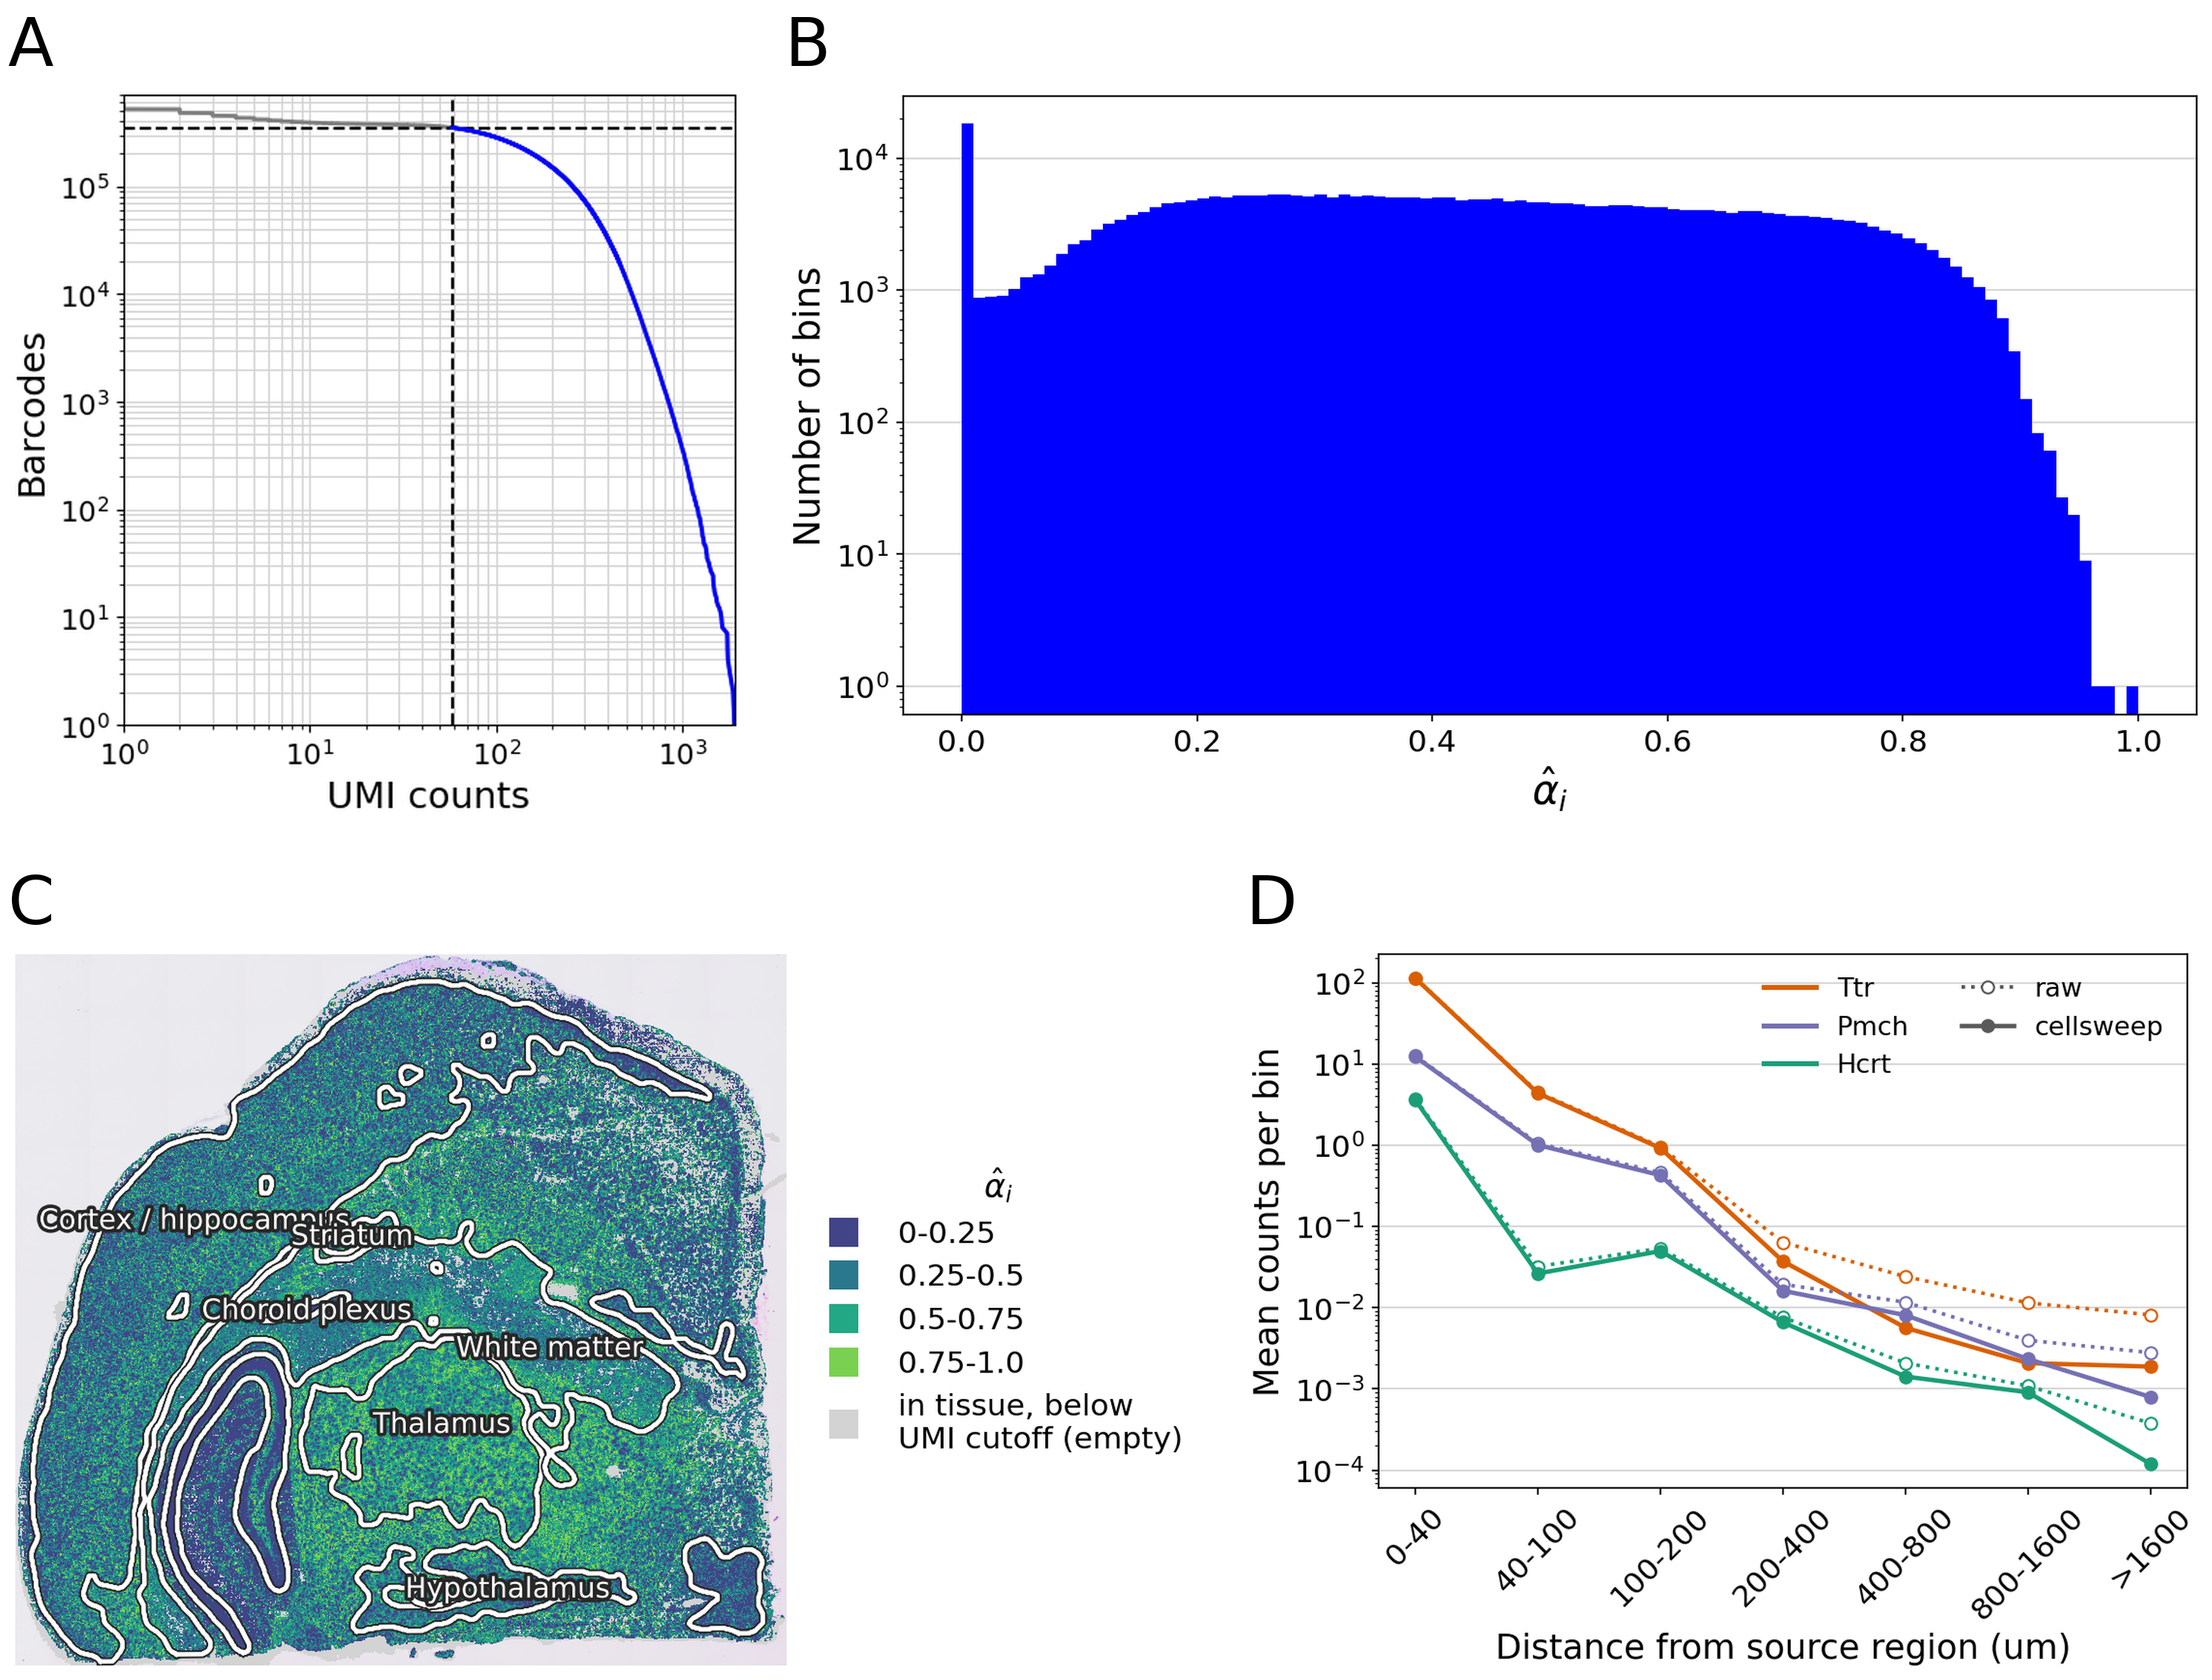

In [3]:
adata = ad.read_h5ad(adata_path_cellsweep)
panel_knee(adata)
non_empty = ~adata.obs["is_empty"].astype(bool).values
alpha = adata.obs.loc[non_empty, "alpha_hat"].values
panel_alpha_histogram(alpha)

below_cutoff = adata.obs.loc[~non_empty & (adata.obs["in_tissue"].values == 1)].copy()
adata = adata[non_empty].copy()
raw, cs = adata.layers["raw"].tocsc(), adata.X.tocsc()
panel_alpha_map(adata.obs, below_cutoff)
panel_gene_decay({g: gene_decay(adata, raw, cs, g) for g in GENES})
compose()

display(show_image(os.path.join(out_dir, "mouse_brain_supplement.png"), width=900))